In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import pandas as pd
import numpy as np
 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
 
import matplotlib.pyplot as plt
 
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Libraries Loaded Successfully")
print(f"Using device: {device}")


Libraries Loaded Successfully
Using device: cuda


In [3]:

def load_cmapss(file_path, dataset_name):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
 
    columns = ['unit', 'cycle', 'op1', 'op2', 'op3'] + \
              [f'sensor{i}' for i in range(1, 22)]
 
    df.columns = columns
    df['dataset'] = dataset_name
 
    print(dataset_name, "shape:", df.shape)
    return df
 
 
df1 = load_cmapss("train_FD001.txt", "FD001")
df2 = load_cmapss("train_FD002.txt", "FD002")
df3 = load_cmapss("train_FD003.txt", "FD003")
df4 = load_cmapss("train_FD004.txt", "FD004")


FD001 shape: (20631, 27)
FD002 shape: (53759, 27)
FD003 shape: (24720, 27)
FD004 shape: (61249, 27)


In [4]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print("Merged Dataset Shape:", df.shape)
 
df['unit_id'] = df['dataset'] + "_" + df['unit'].astype(str)
print("Total Engines:", df['unit_id'].nunique())
 
# Drop constant/low-variance sensors
drop_cols = ['sensor1', 'sensor5', 'sensor6', 'sensor10',
             'sensor16', 'sensor18', 'sensor19']
df = df.drop(columns=drop_cols)
print("Remaining Columns:", df.columns.tolist())

Merged Dataset Shape: (160359, 27)
Total Engines: 709
Remaining Columns: ['unit', 'cycle', 'op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'dataset', 'unit_id']


In [5]:
max_cycle = df.groupby('unit_id')['cycle'].max().reset_index()
max_cycle.columns = ['unit_id', 'max_cycle']
df = df.merge(max_cycle, on='unit_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df['RUL'] = df['RUL'].clip(upper=125)
df['RUL'] = df['RUL'] / 125.0
df.drop(columns=['max_cycle'], inplace=True)
 
print("RUL Calculation Completed")
print(df[['unit_id', 'cycle', 'RUL']].head())
 


RUL Calculation Completed
   unit_id  cycle  RUL
0  FD001_1      1  1.0
1  FD001_1      2  1.0
2  FD001_1      3  1.0
3  FD001_1      4  1.0
4  FD001_1      5  1.0


In [6]:
engine_ids = df['unit_id'].unique()
train_engines, val_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)
 
train_df = df[df['unit_id'].isin(train_engines)].copy()
val_df   = df[df['unit_id'].isin(val_engines)].copy()
 
print("Train engines:", len(train_engines))
print("Validation engines:", len(val_engines))
 
train_df = train_df.sort_values(['unit_id', 'cycle'])
val_df   = val_df.sort_values(['unit_id', 'cycle'])


Train engines: 567
Validation engines: 142


In [7]:
feature_cols = ['op1', 'op2', 'op3'] + \
               [col for col in df.columns if 'sensor' in col]
 
print("Total Features:", len(feature_cols))
print(feature_cols)
 
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
print("Normalization Completed")

Total Features: 17
['op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']
Normalization Completed


In [8]:
def create_sequences(dataframe, seq_length, feature_cols):
    X, y = [], []
    for unit in dataframe['unit_id'].unique():
        unit_df = dataframe[dataframe['unit_id'] == unit]
        data = unit_df[feature_cols].values
        rul  = unit_df['RUL'].values
        for i in range(len(unit_df) - seq_length):
            X.append(data[i:i + seq_length])
            y.append(rul[i + seq_length - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
 
SEQ_LENGTH = 30
X_train, y_train = create_sequences(train_df, SEQ_LENGTH, feature_cols)
X_val,   y_val   = create_sequences(val_df,   SEQ_LENGTH, feature_cols)
 
print("Rolling Window Created")
print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)

Rolling Window Created
X_train shape: (112309, 30, 17)
X_val shape: (26780, 30, 17)


In [9]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)           # (N, seq_len, features)
        self.y = torch.tensor(y).unsqueeze(1)  # (N, 1)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 
 
BATCH_SIZE = 128
 
train_dataset = RULDataset(X_train, y_train)
val_dataset   = RULDataset(X_val,   y_val)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 128, 64, 32], dropout=0.3):
        super(LSTMModel, self).__init__()
 
        layers = []
        in_size = input_size
 
        for i, hidden in enumerate(hidden_sizes):
            return_seq = (i < len(hidden_sizes) - 1)   # False only for last layer
            layers.append(nn.LSTM(in_size, hidden, batch_first=True))
            in_size = hidden
 
        self.lstm_layers = nn.ModuleList([
            nn.LSTM(input_size if i == 0 else hidden_sizes[i-1], h, batch_first=True)
            for i, h in enumerate(hidden_sizes)
        ])
        self.dropouts = nn.ModuleList([nn.Dropout(dropout) for _ in hidden_sizes])
        self.fc1 = nn.Linear(hidden_sizes[-1], 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
 
    def forward(self, x):
        # x: (batch, seq_len, features)
        for i, (lstm, drop) in enumerate(zip(self.lstm_layers, self.dropouts)):
            x, _ = lstm(x)          # (batch, seq_len, hidden)
            x = drop(x)
            if i < len(self.lstm_layers) - 1:
                pass                 # keep full seq for next layer
            else:
                x = x[:, -1, :]     # take last timestep
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
 

In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 128, 64, 32], dropout=0.3):
        super(GRUModel, self).__init__()
 
        self.gru_layers = nn.ModuleList([
            nn.GRU(input_size if i == 0 else hidden_sizes[i-1], h, batch_first=True)
            for i, h in enumerate(hidden_sizes)
        ])
        self.dropouts = nn.ModuleList([nn.Dropout(dropout) for _ in hidden_sizes])
        self.fc1 = nn.Linear(hidden_sizes[-1], 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
 
    def forward(self, x):
        for i, (gru, drop) in enumerate(zip(self.gru_layers, self.dropouts)):
            x, _ = gru(x)
            x = drop(x)
            if i == len(self.gru_layers) - 1:
                x = x[:, -1, :]     # last timestep only
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [12]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
 
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
 
    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        train_loss, train_mae = 0.0, 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
            train_mae  += torch.mean(torch.abs(preds - y_batch)).item() * len(X_batch)
 
        train_loss /= len(train_loader.dataset)
        train_mae  /= len(train_loader.dataset)
 
        # --- Validation ---
        model.eval()
        val_loss, val_mae = 0.0, 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss  = criterion(preds, y_batch)
                val_loss += loss.item() * len(X_batch)
                val_mae  += torch.mean(torch.abs(preds - y_batch)).item() * len(X_batch)
 
        val_loss /= len(val_loader.dataset)
        val_mae  /= len(val_loader.dataset)
 
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)
 
        print(f"Epoch {epoch:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")
 
    return history
 

In [14]:
def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            all_preds.append(preds)
            all_true.append(y_batch.numpy())
 
    y_pred = np.concatenate(all_preds).flatten()
    y_true = np.concatenate(all_true).flatten()
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
 
    print(f"\n{model_name} Results")
    print(f"RMSE: {rmse}")
    print(f"MAE : {mae}")
    print(f"R2  : {r2}")
 
    return y_pred, y_true

In [15]:
n_features = X_train.shape[2]
 
lstm_model = LSTMModel(input_size=n_features, hidden_sizes=[128, 128, 64, 32], dropout=0.3)
print(lstm_model)
 
history_lstm = train_model(lstm_model, train_loader, val_loader, epochs=50)
 

LSTMModel(
  (lstm_layers): ModuleList(
    (0): LSTM(17, 128, batch_first=True)
    (1): LSTM(128, 128, batch_first=True)
    (2): LSTM(128, 64, batch_first=True)
    (3): LSTM(64, 32, batch_first=True)
  )
  (dropouts): ModuleList(
    (0-3): 4 x Dropout(p=0.3, inplace=False)
  )
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Epoch  1/50 | Train Loss: 0.1151 | Train MAE: 0.2992 | Val Loss: 0.1105 | Val MAE: 0.2975
Epoch  2/50 | Train Loss: 0.1105 | Train MAE: 0.2949 | Val Loss: 0.1107 | Val MAE: 0.2980
Epoch  3/50 | Train Loss: 0.0411 | Train MAE: 0.1555 | Val Loss: 0.0341 | Val MAE: 0.1471
Epoch  4/50 | Train Loss: 0.0237 | Train MAE: 0.1147 | Val Loss: 0.0300 | Val MAE: 0.1368
Epoch  5/50 | Train Loss: 0.0206 | Train MAE: 0.1053 | Val Loss: 0.0235 | Val MAE: 0.1278
Epoch  6/50 | Train Loss: 0.0190 | Train MAE: 0.1006 | Val Loss: 0.0239 | Val MAE: 0.1238
Epoch  7/50 | Train Loss: 0.0179 | Trai

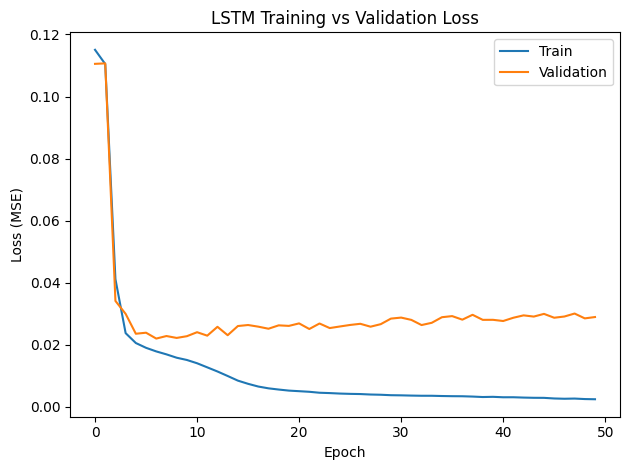


LSTM Results
RMSE: 0.17009752337285974
MAE : 0.13774050772190094
R2  : 0.7377667427062988


In [16]:
plt.figure()
plt.plot(history_lstm['train_loss'], label='Train')
plt.plot(history_lstm['val_loss'],   label='Validation')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_loss_curve.png")
plt.show()
 
y_pred_lstm, y_true = evaluate_model(lstm_model, val_loader, "LSTM")

In [17]:
gru_model = GRUModel(input_size=n_features, hidden_sizes=[128, 128, 64, 32], dropout=0.3)
print(gru_model)
 
history_gru = train_model(gru_model, train_loader, val_loader, epochs=50)

GRUModel(
  (gru_layers): ModuleList(
    (0): GRU(17, 128, batch_first=True)
    (1): GRU(128, 128, batch_first=True)
    (2): GRU(128, 64, batch_first=True)
    (3): GRU(64, 32, batch_first=True)
  )
  (dropouts): ModuleList(
    (0-3): 4 x Dropout(p=0.3, inplace=False)
  )
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Epoch  1/50 | Train Loss: 0.0757 | Train MAE: 0.2164 | Val Loss: 0.0408 | Val MAE: 0.1687
Epoch  2/50 | Train Loss: 0.0279 | Train MAE: 0.1265 | Val Loss: 0.0353 | Val MAE: 0.1555
Epoch  3/50 | Train Loss: 0.0230 | Train MAE: 0.1139 | Val Loss: 0.0273 | Val MAE: 0.1392
Epoch  4/50 | Train Loss: 0.0206 | Train MAE: 0.1069 | Val Loss: 0.0289 | Val MAE: 0.1405
Epoch  5/50 | Train Loss: 0.0189 | Train MAE: 0.1015 | Val Loss: 0.0234 | Val MAE: 0.1265
Epoch  6/50 | Train Loss: 0.0174 | Train MAE: 0.0969 | Val Loss: 0.0319 | Val MAE: 0.1460
Epoch  7/50 | Train Loss: 0.0165 | Train MAE:

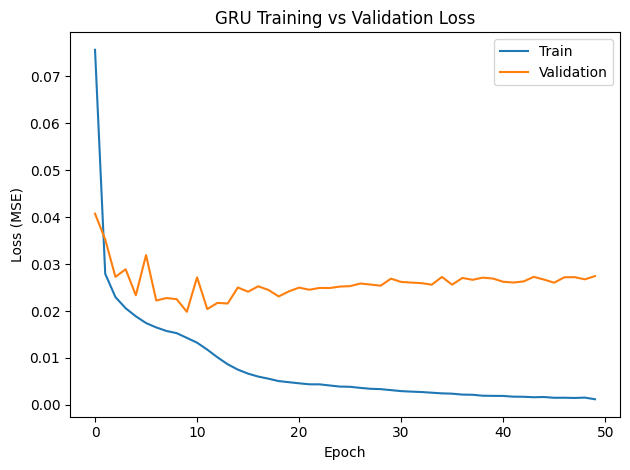


GRU Results
RMSE: 0.1656830935440868
MAE : 0.13578538596630096
R2  : 0.7512012124061584


In [18]:
plt.figure()
plt.plot(history_gru['train_loss'], label='Train')
plt.plot(history_gru['val_loss'],   label='Validation')
plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("gru_loss_curve.png")
plt.show()
 
y_pred_gru, _ = evaluate_model(gru_model, val_loader, "GRU")

In [19]:
 
torch.save(lstm_model.state_dict(), "lstm_rul_model.pth")
torch.save(gru_model.state_dict(),  "gru_rul_model.pth")
print("Models saved successfully")

Models saved successfully


In [20]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
from torch.utils.data import DataLoader

In [21]:
class RULScaler:
    """Mimics MinMaxScaler interface for RUL clipped at 125."""
    def transform(self, arr):
        return np.array(arr, dtype=np.float32) / 125.0
 
    def inverse_transform(self, arr):
        return np.array(arr, dtype=np.float32) * 125.0
 
rul_scaler = RULScaler()

In [32]:
def load_dataset(path, dataset_name):
    df = pd.read_csv(path, sep=r"\s+", header=None)

    # ❗ FIX 1: remove underscore → must match training (sensor1, not sensor_1)
    columns = ['unit', 'cycle', 'op1', 'op2', 'op3'] + \
              [f'sensor{i}' for i in range(1, 22)]

    # ❗ FIX 2: remove extra columns from file (CRITICAL for KeyError)
    df = df.iloc[:, :len(columns)]

    df.columns = columns

    # ❗ FIX 3: clean column names (hidden space issues)
    df.columns = df.columns.str.strip()

    df['dataset'] = dataset_name
    return df


test1 = load_dataset("test_FD001.txt", "FD001")
test2 = load_dataset("test_FD002.txt", "FD002")
test3 = load_dataset("test_FD003.txt", "FD003")
test4 = load_dataset("test_FD004.txt", "FD004")


rul1 = pd.read_csv("RUL_FD001.txt", sep=r"\s+", header=None, names=['RUL'])
rul2 = pd.read_csv("RUL_FD002.txt", sep=r"\s+", header=None, names=['RUL'])
rul3 = pd.read_csv("RUL_FD003.txt", sep=r"\s+", header=None, names=['RUL'])
rul4 = pd.read_csv("RUL_FD004.txt", sep=r"\s+", header=None, names=['RUL'])


print("Test files loaded:")
for name, d in [("FD001", test1), ("FD002", test2),
                ("FD003", test3), ("FD004", test4)]:
    print(f"  {name}: {d.shape}")




Test files loaded:
  FD001: (13096, 27)
  FD002: (33991, 27)
  FD003: (16596, 27)
  FD004: (41214, 27)


In [39]:
print(test1.columns)

Index(['unit', 'cycle', 'op1', 'op2', 'op3', 'sensor1', 'sensor2', 'sensor3',
       'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9',
       'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15',
       'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21',
       'dataset'],
      dtype='str')


In [50]:
# ==========================================================
# STEP 2 : ADD RUL TO TEST DATA (FINAL STABLE VERSION)
# ==========================================================

def add_rul_to_test(df_test, rul_df):
    df_test = df_test.copy()

    # ✅ ensure unit is numeric and clean
    df_test['unit'] = pd.to_numeric(df_test['unit'], errors='coerce')
    df_test = df_test.dropna(subset=['unit'])
    df_test['unit'] = df_test['unit'].astype(int)

    # map: unit → final RUL
    rul_map = {i + 1: rul_df['RUL'].iloc[i] for i in range(len(rul_df))}

    # get max cycle per unit
    max_cycles = df_test.groupby('unit')['cycle'].max().to_dict()

    # ✅ compute RUL WITHOUT groupby.apply (stable)
    df_test['RUL'] = df_test.apply(
        lambda row: rul_map[row['unit']] + (max_cycles[row['unit']] - row['cycle']),
        axis=1
    )

    # create unique id
    df_test['unit_id'] = df_test['dataset'] + "_" + df_test['unit'].astype(str)

    # clip RUL (same as training)
    df_test['RUL'] = df_test['RUL'].clip(upper=125)

    return df_test


# ==========================================================
# APPLY FUNCTION TO ALL TEST SETS
# ==========================================================

test1 = add_rul_to_test(test1, rul1)
test2 = add_rul_to_test(test2, rul2)
test3 = add_rul_to_test(test3, rul3)
test4 = add_rul_to_test(test4, rul4)


# ==========================================================
# COMBINE ALL TEST DATA
# ==========================================================

df_test = pd.concat([test1, test2, test3, test4], ignore_index=True)

print("✅ Combined test shape:", df_test.shape)
print("Columns:", df_test.columns.tolist())
print("RUL range:", df_test['RUL'].min(), "→", df_test['RUL'].max())

✅ Combined test shape: (104897, 29)
Columns: ['unit', 'cycle', 'op1', 'op2', 'op3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21', 'dataset', 'RUL', 'unit_id']
RUL range: 6 → 125


In [51]:
# ==========================================================
# STEP 3 : TEST DATA PREPROCESSING (MATCH TRAINING)
# ==========================================================

# Same columns dropped in training
DROP_COLS = ['sensor1', 'sensor5', 'sensor6', 'sensor10',
             'sensor16', 'sensor18', 'sensor19',
             'sensor_16', 'dataset']   # safe for both naming styles

df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns],
             inplace=True, errors='ignore')


# Feature columns (must match training EXACTLY)
feature_cols_test = ['op1', 'op2', 'op3'] + \
                    [col for col in df_test.columns
                     if 'sensor' in col and col != 'sensor_16']


# Scale features using SAME scaler (no fit)
X_test_raw = df_test[feature_cols_test].values
X_test_scaled = scaler.transform(X_test_raw)

df_test[feature_cols_test] = X_test_scaled


# ✅ RUL normalization (same as training)
df_test['RUL'] = df_test['RUL'] / 125.0


print("✅ Test preprocessing completed")
print("Shape:", df_test.shape)
print("Features:", len(feature_cols_test))
print("RUL range:", df_test['RUL'].min().round(4),
      "→", df_test['RUL'].max().round(4))

✅ Test preprocessing completed
Shape: (104897, 21)
Features: 17
RUL range: 0.048 → 1.0


c:\Users\gauth\gpu_env311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
 
SEQ_LENGTH = 30   # must match training
 
def create_sequences(dataframe, seq_length, feature_cols):
    X, y = [], []
    for unit in dataframe['unit_id'].unique():
        unit_df = dataframe[dataframe['unit_id'] == unit]
        data = unit_df[feature_cols].values
        rul  = unit_df['RUL'].values
        for i in range(len(unit_df) - seq_length):
            X.append(data[i:i + seq_length])
            y.append(rul[i + seq_length - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
 
X_test_seq, y_test_seq = create_sequences(df_test, SEQ_LENGTH, feature_cols_test)
 
print(f"✅ Test sequences created")
print(f"   X_test_seq shape : {X_test_seq.shape}")
print(f"   y_test_seq shape : {y_test_seq.shape}")

✅ Test sequences created
   X_test_seq shape : (83788, 30, 17)
   y_test_seq shape : (83788,)


In [ ]:
n_features = X_test_seq.shape[2]
 
lstm_model.eval()
gru_model.eval()
print("✅ Models ready for inference")

✅ Models ready for inference


In [54]:
#sTEP 6 : PREDICT ON TEST DATA
# ==========================================================
 
class RULDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 
 
test_dataset = RULDataset(X_test_seq, y_test_seq)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)
 
 
def predict(model, loader, device):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            all_preds.append(preds)
    return np.concatenate(all_preds).flatten()
 
 
print("Predicting LSTM on test data...")
lstm_pred_scaled = predict(lstm_model, test_loader, device)
print(f"✅ LSTM done — shape: {lstm_pred_scaled.shape}")
 
print("Predicting GRU on test data...")
gru_pred_scaled  = predict(gru_model,  test_loader, device)
print(f"✅ GRU done — shape: {gru_pred_scaled.shape}")

Predicting LSTM on test data...
✅ LSTM done — shape: (83788,)
Predicting GRU on test data...
✅ GRU done — shape: (83788,)


In [55]:
# ==========================================================
# STEP 7 : ENSEMBLE  (0.6 × GRU + 0.4 × LSTM)
# ==========================================================
 
ensemble_pred_scaled = 0.6 * gru_pred_scaled + 0.4 * lstm_pred_scaled
print("✅ Ensemble done (0.6 × GRU + 0.4 × LSTM)")

✅ Ensemble done (0.6 × GRU + 0.4 × LSTM)


In [56]:
# ==========================================================
# STEP 8 : INVERSE TRANSFORM → ACTUAL CYCLE VALUES
# ==========================================================
 
y_pred_lstm     = rul_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()
y_pred_gru      = rul_scaler.inverse_transform(gru_pred_scaled.reshape(-1, 1)).ravel()
y_pred_ensemble = rul_scaler.inverse_transform(ensemble_pred_scaled.reshape(-1, 1)).ravel()
y_true          = rul_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()
 
print("\nSample actual RUL     :", y_true[:5].round(2))
print("Sample LSTM pred      :", y_pred_lstm[:5].round(2))
print("Sample GRU pred       :", y_pred_gru[:5].round(2))
print("Sample Ensemble pred  :", y_pred_ensemble[:5].round(2))


Sample actual RUL     : [113. 117. 116. 115. 114.]
Sample LSTM pred      : [109.13 105.76 105.01 101.67 101.15]
Sample GRU pred       : [111.44 111.01 111.04 110.94 111.08]
Sample Ensemble pred  : [110.51 108.91 108.63 107.23 107.11]


In [57]:
print("\n" + "=" * 52)
print(f"  {'Model':<28} RMSE    MAE")
print("=" * 52)
for name, y_pred in [
    ("LSTM",                     y_pred_lstm),
    ("GRU",                      y_pred_gru),
    ("Ensemble (0.6GRU+0.4LSTM)", y_pred_ensemble),
]:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"  {name:<28} {rmse:.4f}  {mae:.4f}")
print("=" * 52)
 
if np.sqrt(mean_squared_error(y_true, y_pred_gru)) <= \
   np.sqrt(mean_squared_error(y_true, y_pred_lstm)):
    print("✅ GRU is better than LSTM on test set")
    best_model = gru_model
else:
    print("⚠️ LSTM is still better — check GRU training")
    best_model = lstm_model
 


  Model                        RMSE    MAE
  LSTM                         21.7061  18.3065
  GRU                          19.8235  16.5251
  Ensemble (0.6GRU+0.4LSTM)    20.0179  17.0186
✅ GRU is better than LSTM on test set


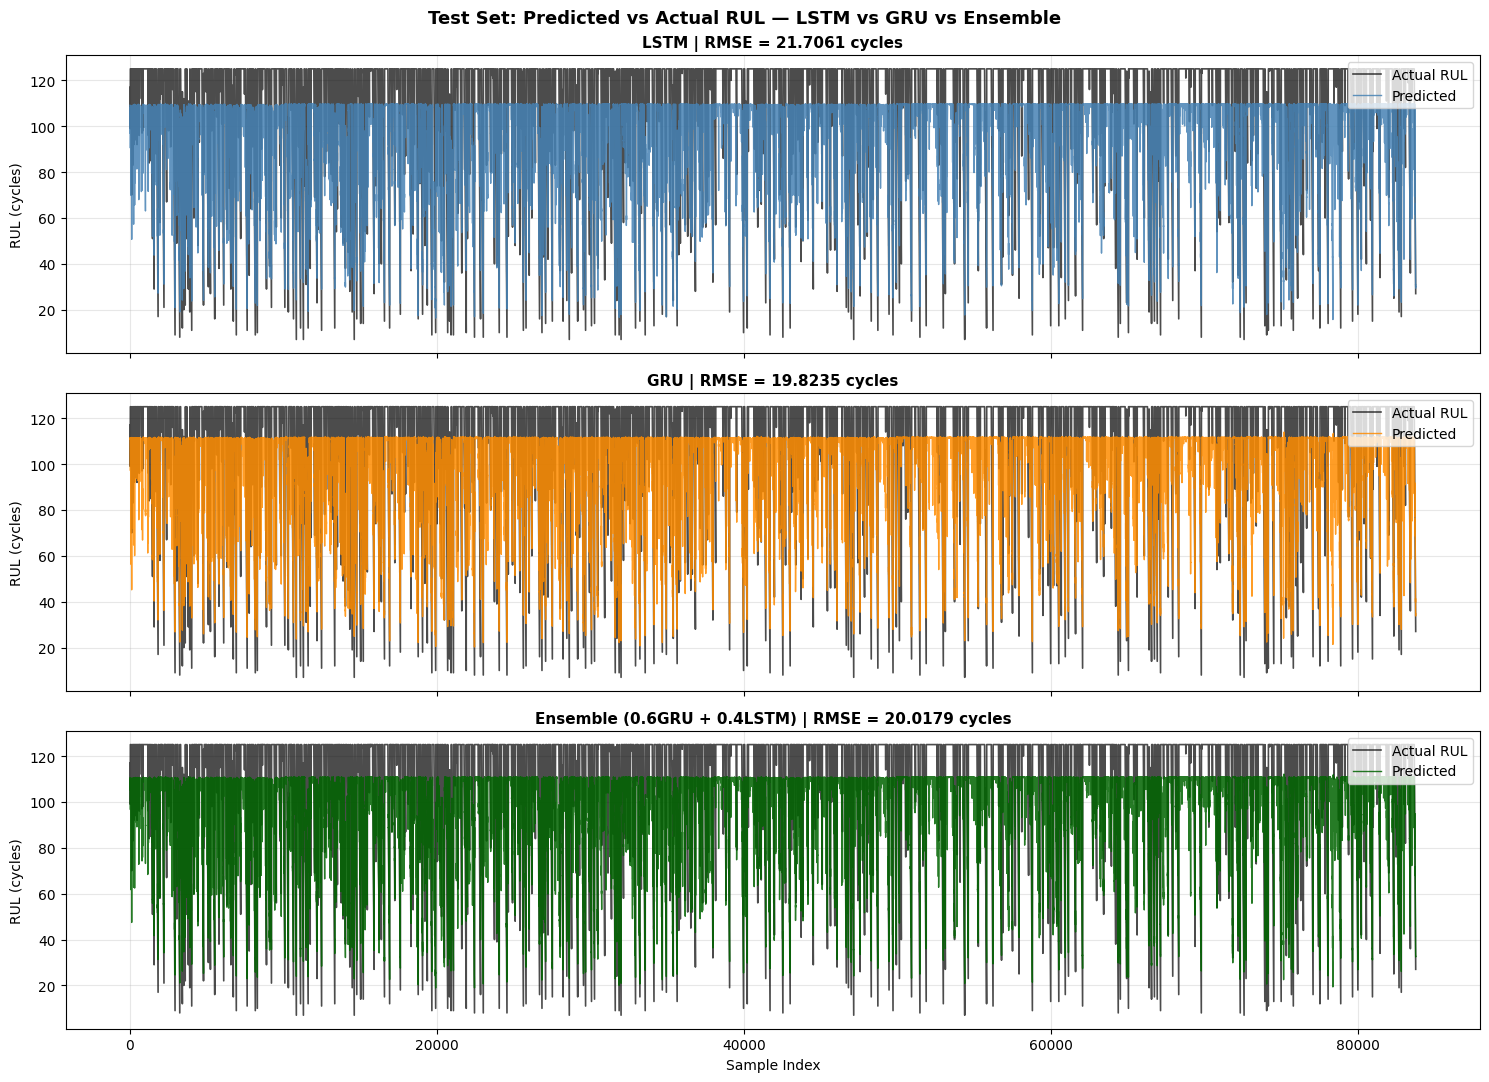

In [59]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
configs = [
    ("LSTM",                          y_pred_lstm,     "steelblue"),
    ("GRU",                           y_pred_gru,      "darkorange"),
    ("Ensemble (0.6GRU + 0.4LSTM)",   y_pred_ensemble, "darkgreen"),
]
 
for ax, (name, y_pred, color) in zip(axes, configs):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.plot(y_true,  label="Actual RUL",  color="black",  linewidth=1.2, alpha=0.7)
    ax.plot(y_pred,  label="Predicted",   color=color,    linewidth=1.0, alpha=0.85)
    ax.set_title(f"{name} | RMSE = {rmse:.4f} cycles",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("RUL (cycles)")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
 
axes[-1].set_xlabel("Sample Index")
plt.suptitle("Test Set: Predicted vs Actual RUL — LSTM vs GRU vs Ensemble",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
plt.show()


In [60]:
def get_alert(rul):
    """Classify engine health based on predicted RUL (cycles)."""
    if rul > 50:
        return "NORMAL"
    elif rul > 20:
        return "WARNING"
    else:
        return "CRITICAL"
 
 
print("\nAlert Thresholds Defined:")
print("  🟢 NORMAL   : RUL > 50 cycles → routine monitoring")
print("  🟡 WARNING  : RUL 20-50 cycles → schedule maintenance")
print("  🔴 CRITICAL : RUL ≤ 20 cycles → immediate action")
 
alerts = [get_alert(r) for r in y_pred_ensemble]
dist   = Counter(alerts)
total  = len(alerts)
 
print("\n" + "=" * 48)
print("  Alert Distribution on Test Set (Ensemble)")
print("=" * 48)
for level in ["NORMAL", "WARNING", "CRITICAL"]:
    count = dist[level]
    pct   = 100 * count / total
    bar   = "█" * int(pct / 2)
    print(f"  {level:<10}: {count:>7,} samples ({pct:5.1f}%)  {bar}")
print("=" * 48)
 


Alert Thresholds Defined:
  🟢 NORMAL   : RUL > 50 cycles → routine monitoring
  🟡 WARNING  : RUL 20-50 cycles → schedule maintenance
  🔴 CRITICAL : RUL ≤ 20 cycles → immediate action

  Alert Distribution on Test Set (Ensemble)
  NORMAL    :  79,256 samples ( 94.6%)  ███████████████████████████████████████████████
  CRITICAL  :      13 samples (  0.0%)  


In [61]:
# --- Results DataFrame ---
results_df = pd.DataFrame({
    "Actual_RUL"   : y_true.round(1),
    "Predicted_RUL": y_pred_ensemble.round(1),
    "Alert"        : alerts
})
 
print("\n── 🟢 NORMAL samples ──────────────────────────")
print(results_df[results_df["Alert"] == "NORMAL"].head(5).to_string(index=False))
print("\n── 🟡 WARNING samples ─────────────────────────")
print(results_df[results_df["Alert"] == "WARNING"].head(5).to_string(index=False))
print("\n── 🔴 CRITICAL samples ────────────────────────")
print(results_df[results_df["Alert"] == "CRITICAL"].head(5).to_string(index=False))


── 🟢 NORMAL samples ──────────────────────────
 Actual_RUL  Predicted_RUL  Alert
      113.0     110.500000 NORMAL
      117.0     108.900002 NORMAL
      116.0     108.599998 NORMAL
      115.0     107.199997 NORMAL
      114.0     107.099998 NORMAL

── 🟡 WARNING samples ─────────────────────────
 Actual_RUL  Predicted_RUL   Alert
       73.0      48.500000 WARNING
       72.0      47.400002 WARNING
       71.0      47.799999 WARNING
       70.0      48.000000 WARNING
       36.0      50.000000 WARNING

── 🔴 CRITICAL samples ────────────────────────
 Actual_RUL  Predicted_RUL    Alert
       15.0      19.900000 CRITICAL
       14.0      19.500000 CRITICAL
       12.0      19.200001 CRITICAL
       11.0      19.100000 CRITICAL
       10.0      18.900000 CRITICAL


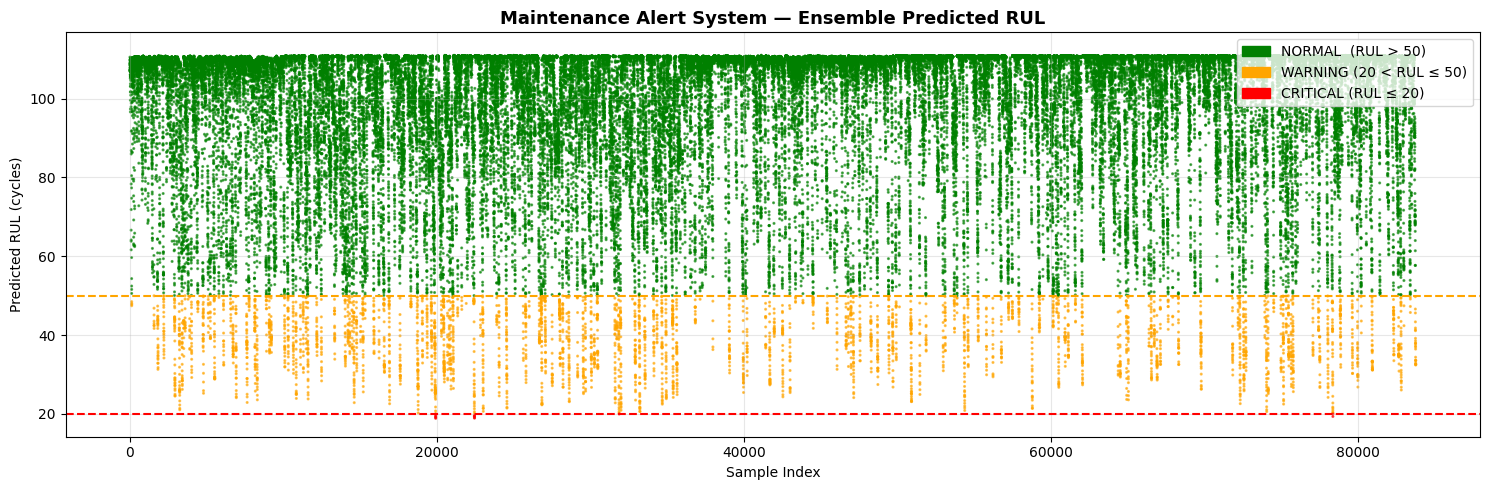

In [62]:
color_map    = {"NORMAL": "green", "WARNING": "orange", "CRITICAL": "red"}
point_colors = [color_map[a] for a in alerts]
 
plt.figure(figsize=(15, 5))
plt.scatter(range(len(y_pred_ensemble)), y_pred_ensemble,
            c=point_colors, s=1.5, alpha=0.6)
plt.axhline(50, color="orange", linestyle="--", linewidth=1.5,
            label="Warning threshold (50)")
plt.axhline(20, color="red",    linestyle="--", linewidth=1.5,
            label="Critical threshold (20)")
 
legend_handles = [
    Patch(color="green",  label="NORMAL  (RUL > 50)"),
    Patch(color="orange", label="WARNING (20 < RUL ≤ 50)"),
    Patch(color="red",    label="CRITICAL (RUL ≤ 20)"),
]
plt.legend(handles=legend_handles, loc="upper right", fontsize=10)
plt.title("Maintenance Alert System — Ensemble Predicted RUL",
          fontsize=13, fontweight="bold")
plt.xlabel("Sample Index")
plt.ylabel("Predicted RUL (cycles)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("alert_scatter.png", dpi=150)
plt.show()


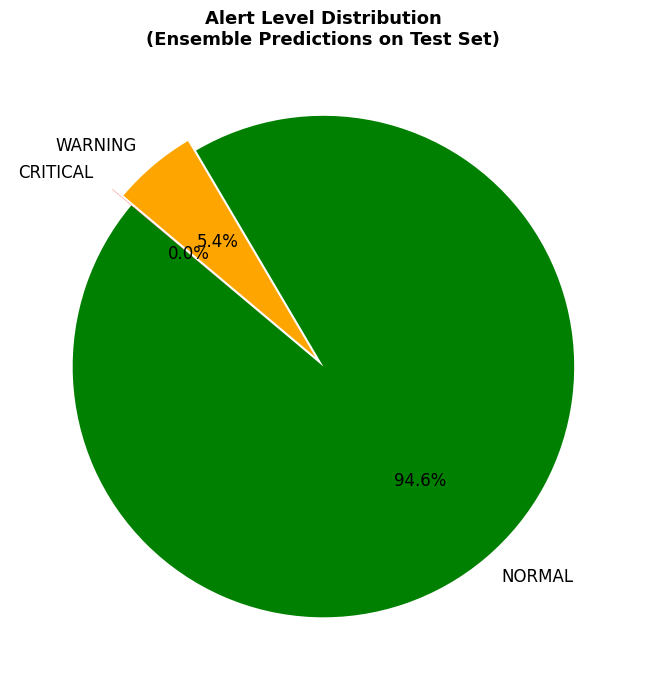

In [63]:
labels  = ["NORMAL", "WARNING", "CRITICAL"]
sizes   = [dist[l] for l in labels]
colors  = ["green", "orange", "red"]
explode = (0, 0.05, 0.1)
 
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct="%1.1f%%", startangle=140,
        textprops={"fontsize": 12})
plt.title("Alert Level Distribution\n(Ensemble Predictions on Test Set)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("alert_pie.png", dpi=150)
plt.show()

In [64]:

torch.save(lstm_model.state_dict(), "lstm_rul_model.pth")
torch.save(gru_model.state_dict(),  "gru_rul_model.pth")
torch.save(best_model.state_dict(), "best_rul_model.pth")
print("✅ All models saved (.pth)")


✅ All models saved (.pth)


In [65]:
cache = {
    'df'               : df,
    'train_df'         : train_df,
    'val_df'           : val_df,
    'df_test'          : df_test,
    'rul_test'         : y_true,
    'X_train_seq'      : X_train,
    'y_train_seq'      : y_train,
    'X_val_seq'        : X_val,
    'y_val_seq'        : y_val,
    'X_test_seq'       : X_test_seq,
    'y_test_seq'       : y_test_seq,
    'scaler'           : scaler,
    'rul_scaler'       : rul_scaler,
    'window_size'      : SEQ_LENGTH,
    'feature_cols'     : feature_cols_test,
    'y_pred_lstm'      : y_pred_lstm,
    'y_pred_gru'       : y_pred_gru,
    'y_pred_ensemble'  : y_pred_ensemble,
    'alerts'           : alerts,
    'results_df'       : results_df,
}
 
with open("session_cache.pkl", "wb") as f:
    pickle.dump(cache, f)
 
print("✅ Session cache saved successfully")
print(f"   Keys saved: {list(cache.keys())}")

✅ Session cache saved successfully
   Keys saved: ['df', 'train_df', 'val_df', 'df_test', 'rul_test', 'X_train_seq', 'y_train_seq', 'X_val_seq', 'y_val_seq', 'X_test_seq', 'y_test_seq', 'scaler', 'rul_scaler', 'window_size', 'feature_cols', 'y_pred_lstm', 'y_pred_gru', 'y_pred_ensemble', 'alerts', 'results_df']
